In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print(os.getcwd())
os.chdir("../../soge-home/projects/mistral/mans4178/schools")
print(os.getcwd())

/hn01-home/mans4178
/lustre/soge1/projects/mistral/mans4178/schools


In [3]:
ISO3 = "UGA"

### Prepare survey data

Household survey source:
https://microdata.worldbank.org/index.php/catalog/3902/

In [4]:
survey = pd.read_csv("validation/survey_data/UGA/UGA_2019_UNPS_v03_M_CSV/gsec4.csv")

In [5]:
print("Number of survey responses: "+str(len(survey)))
print("Number of non-empty responses: "+str(survey.s4q14.count()))

Number of survey responses: 14494
Number of non-empty responses: 5174


In [6]:
# Filter empty responses
survey = survey[survey["s4q14"].notnull()]

In [7]:
# Filter not tertiary
survey = survey[(survey['s4q10'] >= 10) & (survey['s4q10'] <=39)]

In [8]:
print("Number of non-empty, primary and secondary schools only responses: "+str(survey.s4q14.count()))

Number of non-empty, primary and secondary schools only responses: 4109


In [9]:
# Filter only walking 
survey = survey[survey["s4q14b"]==1]

# Filter only not-walking 
#survey = survey[survey["s4q14b"]!=1]

In [10]:
print("Number of non-empty, primary and secondary schools, walking only responses: "+str(survey.s4q14.count()))

Number of non-empty, primary and secondary schools, walking only responses: 3925


In [11]:
tt_col = "s4q14"
weight_col = None

### Import model data

In [12]:
df_summary_1km = pd.read_csv(
    f"model_1km/outputs/jrc/{ISO3}/analysis/ttpop_nat__{ISO3}.csv", 
    index_col=0)

df_summary_90m = pd.read_csv(
    f"model_90m/outputs/jrcwalking/{ISO3}/analysis/ttpop_nat__{ISO3}.csv", 
    index_col=0)

### Plot distributions (nationally)

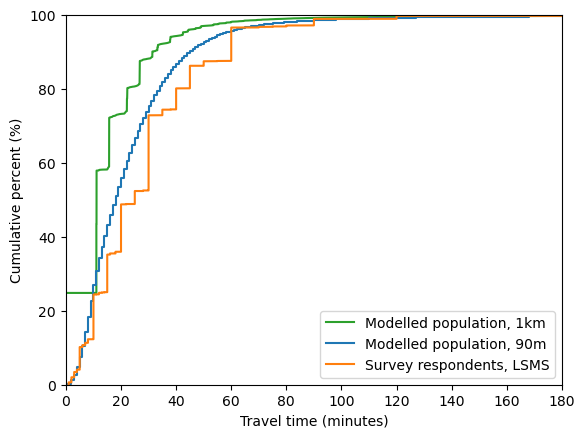

In [13]:
fig, ax = plt.subplots()
sns.ecdfplot(data=df_summary_1km, x="traveltime", weights="pop", stat="percent", label="Modelled population, 1km", color=sns.color_palette()[2])
sns.ecdfplot(data=df_summary_90m, x="traveltime", weights="pop", stat="percent", label="Modelled population, 90m", color=sns.color_palette()[0])
sns.ecdfplot(data=survey, x=tt_col, weights=weight_col, stat="percent", label="Survey respondents, LSMS", color=sns.color_palette()[1])
ax.set_xlim([0, 180])
ax.set_ylim([0, 100])
ax.set_xlabel("Travel time (minutes)")
ax.set_ylabel("Cumulative percent (%)")
ax.legend(loc ='lower right')
plt.show()

### Compare CDFs (areas between curves)

In [14]:
import validation.ipynb.compare_cdfs as compare_cdfs

In [15]:
metrics_90m = compare_cdfs.compare_cdfs(df_summary_90m,
                                        survey,
                                        tmax=120,
                                        time_col=tt_col, 
                                        weight_col=weight_col)

In [16]:
metrics_1km = compare_cdfs.compare_cdfs(df_summary_1km,
                                        survey,
                                        tmax=120,
                                        time_col=tt_col, 
                                        weight_col=weight_col)

In [18]:
table = pd.DataFrame([metrics_90m, metrics_1km], index=["90m model", "1km model"])
table = table.reset_index().rename(columns={"index": "model"})
table.insert(0, "ISO3", ISO3)
table.to_csv(f"validation/model_comp/cdf_metrics__{ISO3}.csv")
table

,ISO3,model,A+,A-,Aabs,A+_norm,A-_norm,Aabs_norm
0,UGA,90m model,4.306701,0.166067,4.472768,0.035889,0.001384,0.037273
1,UGA,1km model,11.328935,0.010789,11.339725,0.094408,0.000090,0.094498
